In [101]:
from autots import AutoTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
#!pip install tensorflow

In [6]:
#!pip install autots

In [102]:
#loading data
data = pd.read_csv("Foreign_Exchange_Rates.xls")
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [103]:
data.columns

Index(['Unnamed: 0', 'Time Serie', 'AUSTRALIA - AUSTRALIAN DOLLAR/US$',
       'EURO AREA - EURO/US$', 'NEW ZEALAND - NEW ZELAND DOLLAR/US$',
       'UNITED KINGDOM - UNITED KINGDOM POUND/US$', 'BRAZIL - REAL/US$',
       'CANADA - CANADIAN DOLLAR/US$', 'CHINA - YUAN/US$',
       'HONG KONG - HONG KONG DOLLAR/US$', 'INDIA - INDIAN RUPEE/US$',
       'KOREA - WON/US$', 'MEXICO - MEXICAN PESO/US$',
       'SOUTH AFRICA - RAND/US$', 'SINGAPORE - SINGAPORE DOLLAR/US$',
       'DENMARK - DANISH KRONE/US$', 'JAPAN - YEN/US$',
       'MALAYSIA - RINGGIT/US$', 'NORWAY - NORWEGIAN KRONE/US$',
       'SWEDEN - KRONA/US$', 'SRI LANKA - SRI LANKAN RUPEE/US$',
       'SWITZERLAND - FRANC/US$', 'TAIWAN - NEW TAIWAN DOLLAR/US$',
       'THAILAND - BAHT/US$', 'Unnamed: 24'],
      dtype='object')

In [104]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 5217 non-null   int64  
 1   Time Serie                                 5217 non-null   object 
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object 
 3   EURO AREA - EURO/US$                       5217 non-null   object 
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object 
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object 
 6   BRAZIL - REAL/US$                          5217 non-null   object 
 7   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object 
 8   CHINA - YUAN/US$                           5217 non-null   object 
 9   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   object 
 10  INDIA - INDIAN RUPEE/US$

#Pre-Processing code here

In [105]:
# Drop useless columns
data = data.drop(columns=["Unnamed: 0", "Unnamed: 24"])

# Rename date column for convenience
data = data.rename(columns={"Time Serie": "Date"})

# Convert Date to datetime
data["Date"] = pd.to_datetime(data["Date"], format="%d-%m-%Y")

# Set Date as index (VERY IMPORTANT for time series)
data = data.set_index("Date")

# Convert all other columns to numeric
data = data.apply(pd.to_numeric, errors='coerce')

# Check again
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5217 entries, 2000-01-03 to 2019-12-31
Data columns (total 22 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5019 non-null   float64
 1   EURO AREA - EURO/US$                       5019 non-null   float64
 2   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5019 non-null   float64
 3   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5019 non-null   float64
 4   BRAZIL - REAL/US$                          5019 non-null   float64
 5   CANADA - CANADIAN DOLLAR/US$               5019 non-null   float64
 6   CHINA - YUAN/US$                           5020 non-null   float64
 7   HONG KONG - HONG KONG DOLLAR/US$           5019 non-null   float64
 8   INDIA - INDIAN RUPEE/US$                   5018 non-null   float64
 9   KOREA - WON/US$                            5019 non-null   float64
 10  MEXICO

In [106]:
data.isna().sum()

AUSTRALIA - AUSTRALIAN DOLLAR/US$            198
EURO AREA - EURO/US$                         198
NEW ZEALAND - NEW ZELAND DOLLAR/US$          198
UNITED KINGDOM - UNITED KINGDOM POUND/US$    198
BRAZIL - REAL/US$                            198
CANADA - CANADIAN DOLLAR/US$                 198
CHINA - YUAN/US$                             197
HONG KONG - HONG KONG DOLLAR/US$             198
INDIA - INDIAN RUPEE/US$                     199
KOREA - WON/US$                              198
MEXICO - MEXICAN PESO/US$                    198
SOUTH AFRICA - RAND/US$                      198
SINGAPORE - SINGAPORE DOLLAR/US$             198
DENMARK - DANISH KRONE/US$                   198
JAPAN - YEN/US$                              198
MALAYSIA - RINGGIT/US$                       198
NORWAY - NORWEGIAN KRONE/US$                 198
SWEDEN - KRONA/US$                           198
SRI LANKA - SRI LANKAN RUPEE/US$             198
SWITZERLAND - FRANC/US$                      198
TAIWAN - NEW TAIWAN 

In [107]:
# Option 1: Forward fill (best for time-series)
data = data.fillna(method='ffill')

C:\Users\Farhaan\AppData\Local\Temp\ipykernel_34480\712736513.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


In [108]:
data.isnull().sum()

AUSTRALIA - AUSTRALIAN DOLLAR/US$            0
EURO AREA - EURO/US$                         0
NEW ZEALAND - NEW ZELAND DOLLAR/US$          0
UNITED KINGDOM - UNITED KINGDOM POUND/US$    0
BRAZIL - REAL/US$                            0
CANADA - CANADIAN DOLLAR/US$                 0
CHINA - YUAN/US$                             0
HONG KONG - HONG KONG DOLLAR/US$             0
INDIA - INDIAN RUPEE/US$                     0
KOREA - WON/US$                              0
MEXICO - MEXICAN PESO/US$                    0
SOUTH AFRICA - RAND/US$                      0
SINGAPORE - SINGAPORE DOLLAR/US$             0
DENMARK - DANISH KRONE/US$                   0
JAPAN - YEN/US$                              0
MALAYSIA - RINGGIT/US$                       0
NORWAY - NORWEGIAN KRONE/US$                 0
SWEDEN - KRONA/US$                           0
SRI LANKA - SRI LANKAN RUPEE/US$             0
SWITZERLAND - FRANC/US$                      0
TAIWAN - NEW TAIWAN DOLLAR/US$               0
THAILAND - BA

In [109]:
print(data.index.is_monotonic_increasing)

True


In [110]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5217 entries, 2000-01-03 to 2019-12-31
Data columns (total 22 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   float64
 1   EURO AREA - EURO/US$                       5217 non-null   float64
 2   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   float64
 3   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   float64
 4   BRAZIL - REAL/US$                          5217 non-null   float64
 5   CANADA - CANADIAN DOLLAR/US$               5217 non-null   float64
 6   CHINA - YUAN/US$                           5217 non-null   float64
 7   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   float64
 8   INDIA - INDIAN RUPEE/US$                   5217 non-null   float64
 9   KOREA - WON/US$                            5217 non-null   float64
 10  MEXICO

In [111]:
# EDA code here

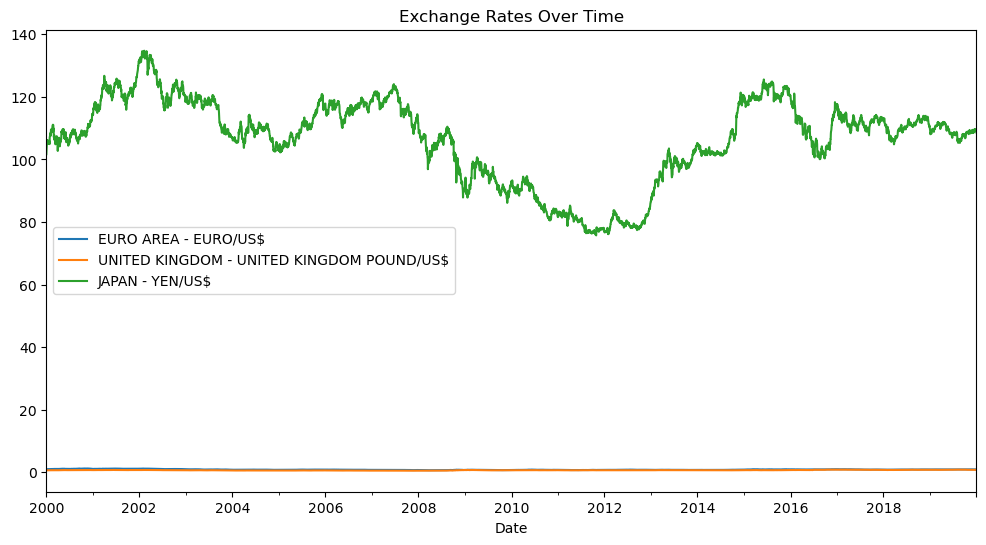

In [112]:
data[[
    "EURO AREA - EURO/US$",
    "UNITED KINGDOM - UNITED KINGDOM POUND/US$",
    "JAPAN - YEN/US$"
]].plot(figsize=(12,6))

plt.title("Exchange Rates Over Time")
plt.show()

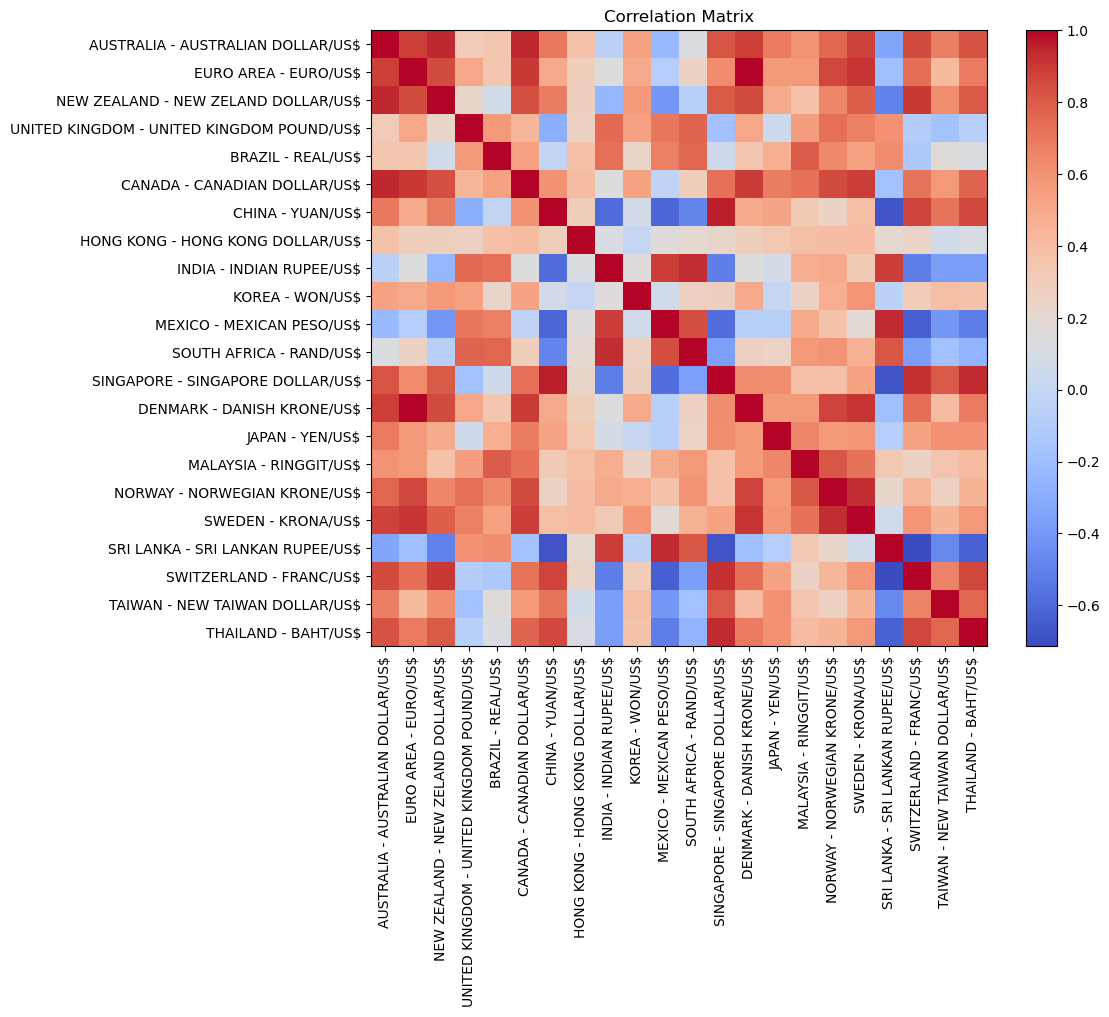

In [113]:
corr = data.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

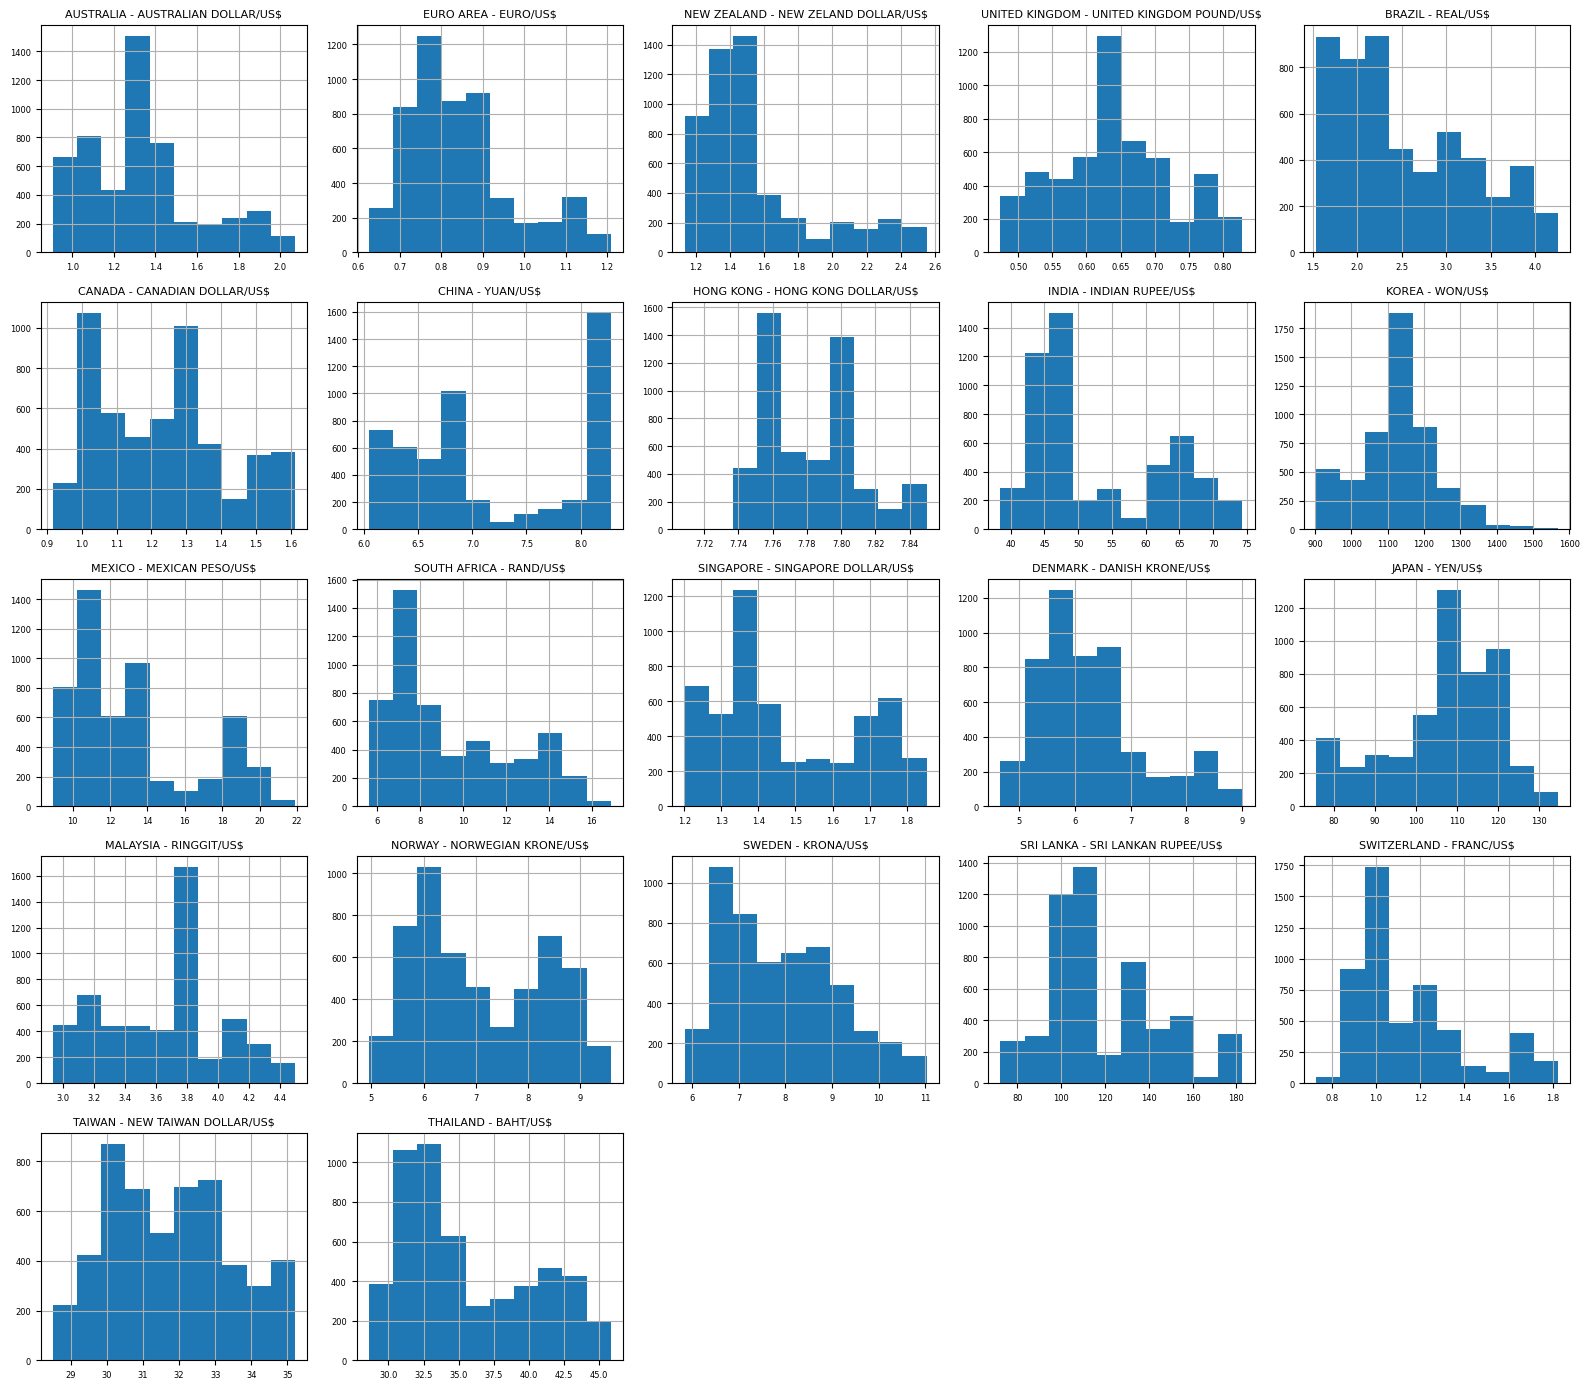

In [114]:
data.hist(figsize=(16,14))

for ax in plt.gcf().axes:
    ax.title.set_size(8)
    ax.xaxis.label.set_size(7)
    ax.yaxis.label.set_size(7)
    ax.tick_params(axis='both', labelsize=6)

plt.tight_layout()
plt.show()

In [115]:
#selecting currency

options = {
    'AUSTRALIAN DOLLAR': 'AUSTRALIA - AUSTRALIAN DOLLAR/US$',
    'EURO': 'EURO AREA - EURO/US$',
    'NEW ZEALAND DOLLAR': 'NEW ZEALAND - NEW ZEALAND DOLLAR/US$',
    'GREAT BRITAIN POUNDS': 'UNITED KINGDOM - UNITED KINGDOM POUND/US$',
    'BRAZILIAN REAL': 'BRAZIL - REAL/US$',
    'CANADIAN DOLLAR': 'CANADA - CANADIAN DOLLAR/US$',
    'CHINESE YUAN$': 'CHINA - YUAN/US$',
    'HONG KONG DOLLAR': 'HONG KONG - HONG KONG DOLLAR/US$',
    'INDIAN RUPEE': 'INDIA - INDIAN RUPEE/US$',
    'KOREAN WON$': 'KOREA - WON/US$',
    'MEXICAN PESO': 'MEXICO - MEXICAN PESO/US$',
    'SOUTH AFRICAN RAND$': 'SOUTH AFRICA - RAND/US$',
    'SINGAPORE DOLLAR': 'SINGAPORE - SINGAPORE DOLLAR/US$',
    'DANISH KRONE': 'DENMARK - DANISH KRONE/US$',
    'JAPANESE YEN$': 'JAPAN - YEN/US$',
    'MALAYSIAN RINGGIT': 'MALAYSIA - RINGGIT/US$',
    'NORWEGIAN KRONE': 'NORWAY - NORWEGIAN KRONE/US$',
    'SWEDEN KRONA': 'SWEDEN - KRONA/US$',
    'SRILANKAN RUPEE': 'SRI LANKA - SRI LANKAN RUPEE/US$',
    'SWISS FRANC': 'SWITZERLAND - FRANC/US$',
    'NEW TAIWAN DOLLAR': 'TAIWAN - NEW TAIWAN DOLLAR/US$',
    'THAI BAHT': 'THAILAND - BAHT/US$'
}

selected_option = 'SRILANKAN RUPEE' #select currency here to train model

In [21]:
target_col = options['SRILANKAN RUPEE']
df = data[[target_col]].copy()
df = df.rename(columns={target_col: 'y'})

In [22]:
# Lag features
df['lag_1'] = df['y'].shift(1)
df['lag_7'] = df['y'].shift(7)
df['lag_30'] = df['y'].shift(30)

In [23]:
# Rolling Statistics (captures trends)

df['rolling_mean_7'] = df['y'].rolling(window=7).mean()
df['rolling_std_7'] = df['y'].rolling(window=7).std()

df['rolling_mean_30'] = df['y'].rolling(window=30).mean()
df['rolling_std_30'] = df['y'].rolling(window=30).std()

In [24]:
# Time-Based Features

df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year

In [25]:
# Drop NaN Values (created by lagging)

df = df.dropna()

In [26]:
# Final Check

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5187 entries, 2000-02-14 to 2019-12-31
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   y                5187 non-null   float64
 1   lag_1            5187 non-null   float64
 2   lag_7            5187 non-null   float64
 3   lag_30           5187 non-null   float64
 4   rolling_mean_7   5187 non-null   float64
 5   rolling_std_7    5187 non-null   float64
 6   rolling_mean_30  5187 non-null   float64
 7   rolling_std_30   5187 non-null   float64
 8   day_of_week      5187 non-null   int32  
 9   month            5187 non-null   int32  
 10  year             5187 non-null   int32  
dtypes: float64(8), int32(3)
memory usage: 425.5 KB


,y,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,day_of_week,month,year
Date,,,,,,,,,,,
2000-02-14,73.65,73.60,73.55,72.30,73.474286,0.292339,73.284000,0.273087,0,2,2000
2000-02-15,73.75,73.65,73.55,72.65,73.502857,0.310200,73.320667,0.258483,1,2,2000
2000-02-16,73.41,73.75,73.50,72.95,73.490000,0.312197,73.336000,0.249214,2,2,2000
2000-02-17,73.65,73.41,73.60,72.95,73.497143,0.315685,73.359333,0.244554,3,2,2000
2000-02-18,73.36,73.65,73.60,73.15,73.462857,0.315685,73.366333,0.241339,4,2,2000


In [84]:
# Train/Test Split

# Split: last 60 days for testing
train = df.iloc[:-60]
test = df.iloc[-60:]

X_train = train.drop(columns=['y'])
y_train = train['y']

X_test = test.drop(columns=['y'])
y_test = test['y']

In [28]:
print(X_train.shape, X_test.shape)

(5127, 10) (60, 10)


In [29]:
#!pip install xgboost

In [ ]:
# Train the Model

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model_xgb.fit(X_train_xgb, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
y_pred = model_xgb.predict(X_test)

In [32]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

MAE: 0.6035
RMSE: 0.6847
MAPE: 0.3333


In [33]:
SRILANKAN_RUPEE_results = []

SRILANKAN_RUPEE_results.append({
    "Model": "XGBoost",
    "MAE": round(mae, 4),
    "RMSE": round(rmse, 4),
    "MAPE": round(mape, 4)
})



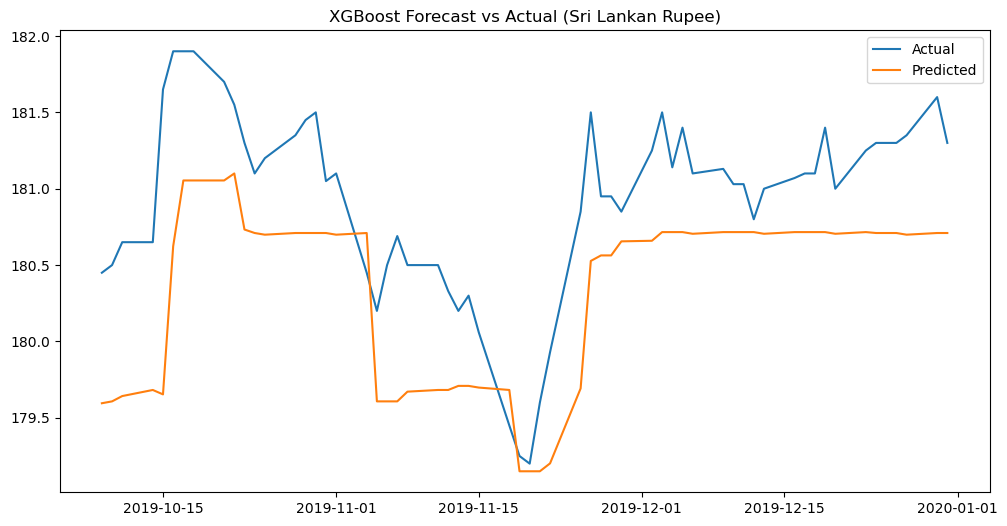

In [34]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.title("XGBoost Forecast vs Actual (Sri Lankan Rupee)")
plt.show()

The XGBoost model demonstrated strong predictive performance, achieving a low Mean Absolute Percentage Error (MAPE) of approximately 0.33%. This indicates that the model was able to accurately capture short-term fluctuations in the exchange rate. The inclusion of lag features and rolling statistics enabled the model to effectively learn temporal dependencies and local trends in the data.

Add insight:

- Handles non-linearity
- Uses feature engineering
- Works well even without strict assumptions

In [35]:
# Prepare Data for ARIMA

series = data[options['SRILANKAN RUPEE']].copy()

# Train/test split (same as before)
train_arima = series.iloc[:-60]
test_arima = series.iloc[-60:]

In [36]:
# Check Stationarity
# ARIMA assumes stationarity. Instead of going too theoretical, we apply a practical approach

result = adfuller(train_arima)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

'''
Interpretation:

p < 0.05 → stationary
p > 0.05 → not stationary → need differencing
'''

ADF Statistic: 0.6190034570680182
p-value: 0.9880747848798246


'\nInterpretation:\n\np < 0.05 → stationary\np > 0.05 → not stationary → need differencing\n'

In [37]:
# Apply Differencing (if needed)
# Most forex series are non-stationary

train_diff = train_arima.diff().dropna()

In [38]:
# Train ARIMA Model

model_arima = ARIMA(train_arima, order=(5,1,0))  # (p,d,q)
model_arima_fit = model_arima.fit()

c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


In [39]:
# forecast

forecast = model_arima_fit.forecast(steps=60)

In [40]:
# Evaluate ARIMA

mae_arima = mean_absolute_error(test_arima, forecast)
rmse_arima = np.sqrt(mean_squared_error(test_arima, forecast))
mape_arima = np.mean(np.abs((test_arima - forecast) / test_arima)) * 100

print(f"MAE: {mae_arima:.4f}")
print(f"RMSE: {rmse_arima:.4f}")
print(f"MAPE: {mape_arima:.4f}")

MAE: 0.8739
RMSE: 0.9786
MAPE: 0.4824


The XGBoost model significantly outperformed the ARIMA model across all evaluation metrics. In particular, XGBoost achieved a lower Mean Absolute Error (0.6035 vs 0.8739) and Root Mean Squared Error (0.6847 vs 0.9786), indicating more accurate predictions. Similarly, the Mean Absolute Percentage Error (MAPE) was lower for XGBoost (0.33%) compared to ARIMA (0.48%), confirming superior relative accuracy.

The superior performance of XGBoost can be attributed to its ability to model complex, non-linear relationships in the data. By incorporating lag features and rolling statistics, the model effectively captured short-term dependencies and local trends in the exchange rate.

Although ARIMA is a well-established statistical model for time-series forecasting, its performance in this case was limited. ARIMA assumes linear relationships and relies heavily on past values of the series, which restricts its ability to capture complex fluctuations and sudden changes commonly observed in financial markets.

Exchange rates are influenced by multiple economic and geopolitical factors, often resulting in non-linear and volatile behaviour. Machine learning models such as XGBoost are better suited to handle such complexity, whereas traditional models like ARIMA may struggle to adapt to rapid changes.

Despite XGBoost outperforming ARIMA, both models achieved relatively low error rates, indicating that exchange rate movements for the Sri Lankan Rupee are reasonably predictable over short horizons.

The results suggest that while traditional statistical models remain useful as benchmarks, machine learning approaches provide a clear advantage in forecasting financial time-series data due to their flexibility and ability to incorporate engineered features.

In conclusion, XGBoost demonstrated superior predictive performance compared to ARIMA for the Sri Lankan Rupee exchange rate. This highlights the effectiveness of machine learning approaches in capturing complex temporal patterns, making them more suitable for real-world financial forecasting applications.

In [41]:
SRILANKAN_RUPEE_results.append({
    "Model": "ARIMA",
    "MAE": round(mae_arima, 4),
    "RMSE": round(rmse_arima, 4),
    "MAPE": round(mape_arima, 4)
})

results = pd.DataFrame(SRILANKAN_RUPEE_results)
results

,Model,MAE,RMSE,MAPE
0,XGBoost,0.6035,0.6847,0.3333
1,ARIMA,0.8739,0.9786,0.4824


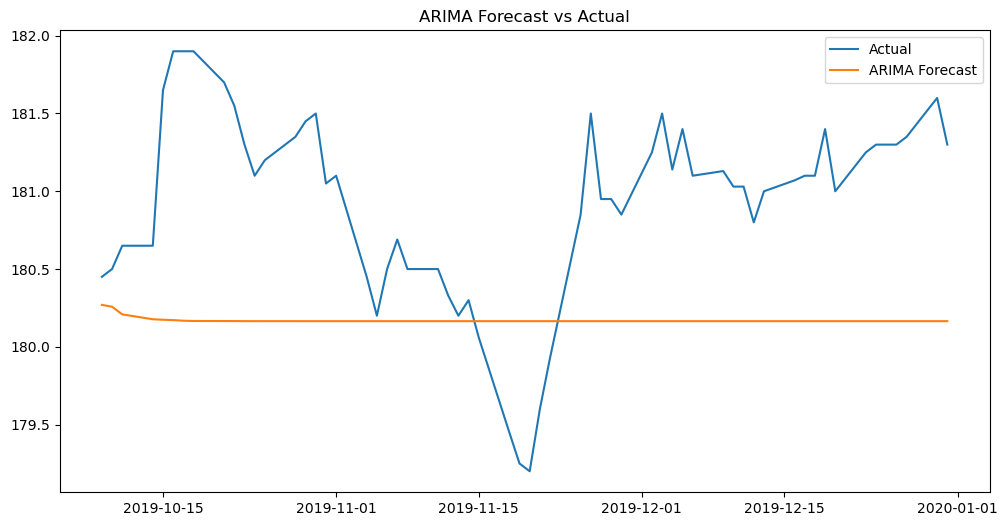

In [42]:
plt.figure(figsize=(12,6))
plt.plot(test_arima.index, test_arima, label="Actual")
plt.plot(test_arima.index, forecast, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

# Prophet Model

In [43]:
#!pip install prophet

In [44]:
# Prepare dataset
df_prophet = data[[options['SRILANKAN RUPEE']]].reset_index()
df_prophet.columns = ['ds', 'y']

In [45]:
# Train/Test Split

train_prophet = df_prophet.iloc[:-60]
test_prophet = df_prophet.iloc[-60:]

In [46]:
model_prophet = Prophet(
    daily_seasonality=True,
    yearly_seasonality=True
)

model_prophet.fit(train_prophet)

18:34:01 - cmdstanpy - INFO - Chain [1] start processing
18:34:05 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
# Create future dataframe for 60 days

future = model_prophet.make_future_dataframe(periods=60)

In [48]:
# forecast

forecast = model_prophet.predict(future)

In [49]:
# Extract the last 60 predictions (corresponding to our test set)

forecast_test = forecast.tail(60)

y_pred_prophet = forecast_test['yhat'].values
y_test_prophet = test_prophet['y'].values

In [50]:
# Evaluate Prophet

mae_prophet = mean_absolute_error(y_test_prophet, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_test_prophet, y_pred_prophet))
mape_prophet = np.mean(np.abs((y_test_prophet - y_pred_prophet) / y_test_prophet)) * 100

print(f"MAE: {mae_prophet:.4f}")
print(f"RMSE: {rmse_prophet:.4f}")
print(f"MAPE: {mape_prophet:.4f}")

MAE: 1.8838
RMSE: 2.1188
MAPE: 1.0401


In [51]:
SRILANKAN_RUPEE_results.append({
    "Model": "Prophet",
    "MAE": round(mae_prophet, 4),
    "RMSE": round(rmse_prophet, 4),
    "MAPE": round(mape_prophet, 4)
})

results = pd.DataFrame(SRILANKAN_RUPEE_results)
results

,Model,MAE,RMSE,MAPE
0,XGBoost,0.6035,0.6847,0.3333
1,ARIMA,0.8739,0.9786,0.4824
2,Prophet,1.8838,2.1188,1.0401


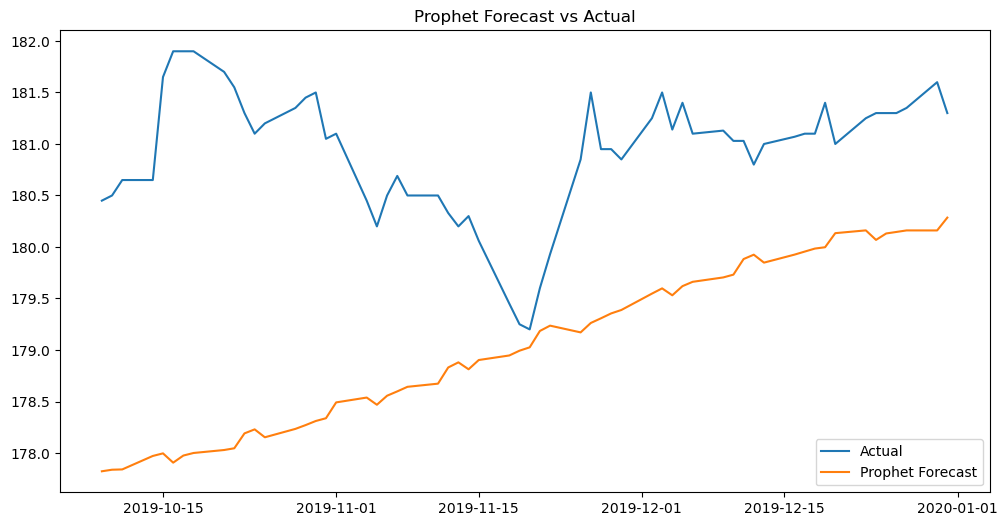

In [52]:
plt.figure(figsize=(12,6))
plt.plot(test_prophet['ds'], y_test_prophet, label="Actual")
plt.plot(test_prophet['ds'], y_pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs Actual")
plt.show()

Among the three models, XGBoost achieved the best performance, followed by ARIMA, while Prophet produced the highest prediction error. This indicates that machine learning approaches were more effective than traditional statistical and decompositional models for forecasting the Sri Lankan Rupee exchange rate.

XGBoost outperformed the other models due to its ability to capture complex, non-linear relationships in the data. By incorporating lag features and rolling statistics, the model effectively learned both short-term dependencies and local trends in the exchange rate.

Prophet produced the weakest results, with significantly higher MAE, RMSE, and MAPE values. This can be attributed to its reliance on strong trend and seasonal components, which are not prominent in foreign exchange rate data.

The results highlight that models designed for structured seasonal data, such as Prophet, may not perform well on highly volatile financial time-series. In contrast, machine learning models like XGBoost, which do not rely on strict assumptions, are better suited for capturing irregular patterns in exchange rate movements.

Overall, the findings suggest that machine learning approaches provide superior predictive performance for exchange rate forecasting compared to traditional statistical and decompositional models. This is primarily due to their flexibility and ability to incorporate additional explanatory features.

## LSTM Model

In [68]:
# Prepare data for LSTM

series = data[options['SRILANKAN RUPEE']].values

In [69]:
# Scale the data (LSTMs are sensitive to scale)

scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1,1))

In [70]:
# Create sequences for LSTM (e.g., using past 30 days to predict next day)

def create_sequences(data, seq_length=30):
    X, y = [], []
    
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
        
    return np.array(X), np.array(y)

X, y = create_sequences(series_scaled, 30)

In [ ]:
# Train/Test split 
X_train_LSTM, X_test_LSTM = X[:-60], X[-60:]
y_train_LSTM, y_test_LSTM = y[:-60], y[-60:]

In [ ]:
# Model

model_lstm = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X_train_LSTM.shape[1], 1)),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train the model

history = model_lstm.fit(
    X_train_LSTM, y_train_LSTM,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0045 - val_loss: 1.3949e-04
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.4331e-04 - val_loss: 1.7652e-04
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.0375e-04 - val_loss: 5.2999e-04
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.7916e-04 - val_loss: 1.8303e-04
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.5380e-04 - val_loss: 7.8061e-04
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.4975e-04 - val_loss: 4.3153e-04
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1.3428e-04 - val_loss: 0.0010
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.2401e-04 - val_loss: 2.0563e-04
Epoch 9/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.1322e-04 - val_loss: 1.7671e-04
Epoch 10/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.3257e-04 - val_loss: 3.7603e-04
Epoch 11/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.0261

In [ ]:
# Predict with LSTM

y_pred_lstm = model_lstm.predict(X_test_LSTM)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


In [ ]:
# Inverse (Scaling) transform to get actual values

y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_lstm = scaler.inverse_transform(y_test_LSTM)

In [76]:
# Evaluate LSTM

mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
mape_lstm = np.mean(np.abs((y_test_lstm - y_pred_lstm) / y_test_lstm)) * 100

print(f"MAE: {mae_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")
print(f"MAPE: {mape_lstm:.4f}")

MAE: 1.1912
RMSE: 1.3373
MAPE: 0.6575


In [78]:
SRILANKAN_RUPEE_results.append({
    "Model": "LSTM",
    "MAE": round(mae_lstm, 4),
    "RMSE": round(rmse_lstm, 4),
    "MAPE": round(mape_lstm, 4)
})
    
results = pd.DataFrame(SRILANKAN_RUPEE_results)
results

,Model,MAE,RMSE,MAPE
0,XGBoost,0.6035,0.6847,0.3333
1,ARIMA,0.8739,0.9786,0.4824
2,Prophet,1.8838,2.1188,1.0401
3,Prophet,1.8838,2.1188,1.0401
4,LSTM,1.1912,1.3373,0.6575


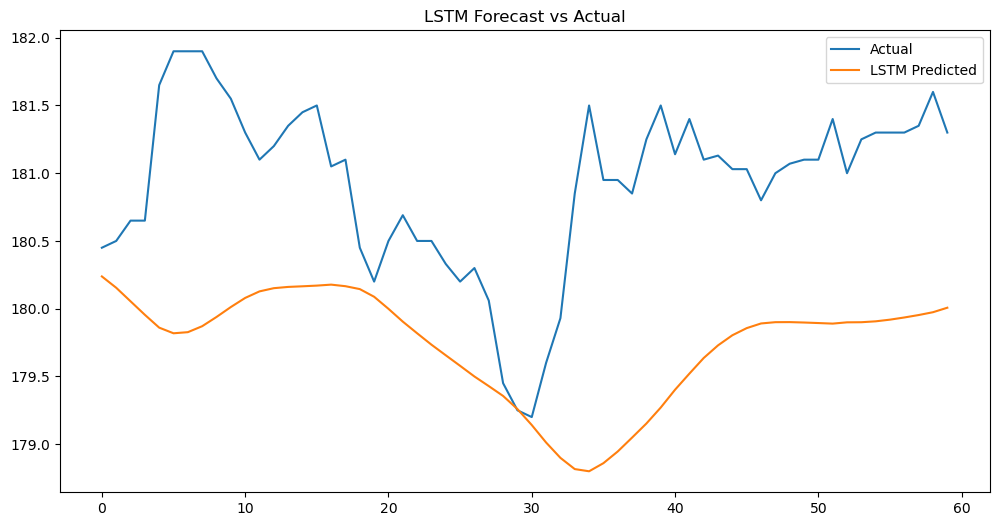

In [79]:
# Plot LSTM results 

plt.figure(figsize=(12,6))
plt.plot(y_test_lstm, label="Actual")
plt.plot(y_pred_lstm, label="LSTM Predicted")
plt.legend()
plt.title("LSTM Forecast vs Actual")
plt.show()

1. LSTM Performance Interpretation

The LSTM model demonstrated moderate performance, achieving a MAPE of approximately 0.66%. While it was able to capture sequential dependencies in the data, it did not outperform the XGBoost model.

2. Why LSTM Did Not Win

Despite its capability to model long-term dependencies, the LSTM model did not achieve the best performance. This may be due to the relatively structured nature of the dataset, where short-term dependencies and engineered features are more informative than long-range patterns.

3. Critical Comparison Insight

The results indicate that traditional machine learning models such as XGBoost can outperform deep learning models in time-series forecasting when appropriate feature engineering is applied.

4. Complexity vs Performance (VERY STRONG POINT)

Although LSTM is a more complex model, it requires careful tuning and greater computational resources. In contrast, XGBoost achieved superior performance with less complexity, making it a more efficient and practical choice for this task.

CONCLUSION

Overall, XGBoost emerged as the best-performing model for forecasting the Sri Lankan Rupee exchange rate, followed by ARIMA and LSTM, while Prophet performed the worst. These findings highlight that model effectiveness depends not only on model complexity but also on the nature of the data. Machine learning models that leverage feature engineering can outperform both traditional statistical models and deep learning approaches in financial time-series forecasting.

In [80]:
# Create models directory if it doesn't exist (for saving models later)

import os

os.makedirs("models", exist_ok=True)

In [81]:
# Save the XGBoost model

import joblib

joblib.dump(model_xgb, "models/SRILANKAN_RUPEE_xgb.pkl")

['models/SRILANKAN_RUPEE_xgb.pkl']

In [87]:
# Load the model and test prediction (Verify It Works)

loaded_model = joblib.load("models/SRILANKAN_RUPEE_xgb.pkl")

# Test prediction
test_pred = loaded_model.predict(X_test[:5])
print(test_pred)

[179.59546 179.6077  179.64249 179.68236 179.6535 ]


In [88]:
model_info = {
    "currency": "SRILANKAN RUPEE",
    "model": "XGBoost",
    "MAE": round(mae, 4),
    "RMSE": round(rmse, 4),
    "MAPE": round(mape, 4)
}

joblib.dump(model_info, "models/SRILANKAN_RUPEE_info.pkl")

['models/SRILANKAN_RUPEE_info.pkl']

### AUTOMATE FOR ALL CURRENCIES for all models

In [116]:
# Setup

os.makedirs("models", exist_ok=True)

results = []

In [117]:
# Feature Engineering

def create_features(df):
    df = df.copy()

    df['lag_1'] = df['y'].shift(1)
    df['lag_7'] = df['y'].shift(7)
    df['lag_30'] = df['y'].shift(30)

    df['rolling_mean_7'] = df['y'].rolling(7).mean()
    df['rolling_std_7'] = df['y'].rolling(7).std()
    df['rolling_mean_30'] = df['y'].rolling(30).mean()
    df['rolling_std_30'] = df['y'].rolling(30).std()

    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['year'] = df.index.year

    return df.dropna()

In [118]:
# Train/Test Split

def split_data(df, target='y', test_size=60):
    train = df.iloc[:-test_size]
    test = df.iloc[-test_size:]
    
    X_train = train.drop(columns=[target])
    y_train = train[target]
    X_test = test.drop(columns=[target])
    y_test = test[target]
    
    return X_train, X_test, y_train, y_test

In [119]:
# LSTM Model

def train_lstm(series):

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series.values.reshape(-1,1))

    seq_len = 30
    X, y = [], []

    for i in range(len(scaled) - seq_len):
        X.append(scaled[i:i+seq_len])
        y.append(scaled[i+seq_len])

    X = np.array(X)
    y = np.array(y)

    X_train, X_test = X[:-60], X[-60:]
    y_train, y_test = y[:-60], y[-60:]

    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True, input_shape=(30,1)),
        LSTM(32, activation='tanh'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    preds = model.predict(X_test)

    preds = scaler.inverse_transform(preds)
    y_test = scaler.inverse_transform(y_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

    return model, mae, rmse, mape

In [121]:
# MASTER LOOP (ALL CURRENCIES + ALL MODELS)

for currency_name, col in options.items():

    print(f"\nProcessing: {currency_name}")

    try:
        # =========================
        # Prepare dataset
        # =========================
        df = data[[col]].copy()
        df = df.rename(columns={col: 'y'})

        df_feat = create_features(df)

        X_train, X_test, y_train, y_test = split_data(df_feat)

        # =========================
        # 1. XGBOOST
        # =========================
        xgb = XGBRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        )

        xgb.fit(X_train, y_train)
        pred_xgb = xgb.predict(X_test)

        xgb_mae = mean_absolute_error(y_test, pred_xgb)
        xgb_rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
        xgb_mape = np.mean(np.abs((y_test - pred_xgb) / y_test)) * 100

        joblib.dump(xgb, f"models/{currency_name}_xgb.pkl")

        results.append([currency_name, "XGBoost", xgb_mae, xgb_rmse, xgb_mape])

        # =========================
        # 2. ARIMA
        # =========================
        arima_train = df['y'].iloc[:-60]
        arima_test = df['y'].iloc[-60:]

        arima_model = ARIMA(arima_train, order=(5,1,0)).fit()
        pred_arima = arima_model.forecast(60)

        arima_mae = mean_absolute_error(arima_test, pred_arima)
        arima_rmse = np.sqrt(mean_squared_error(arima_test, pred_arima))
        arima_mape = np.mean(np.abs((arima_test - pred_arima) / arima_test)) * 100

        results.append([currency_name, "ARIMA", arima_mae, arima_rmse, arima_mape])

        # =========================
        # 3. PROPHET
        # =========================
        prophet_df = df.reset_index()
        prophet_df.columns = ['ds', 'y']

        train_p = prophet_df.iloc[:-60]
        test_p = prophet_df.iloc[-60:]

        model_p = Prophet()
        model_p.fit(train_p)

        future = model_p.make_future_dataframe(periods=60)
        forecast = model_p.predict(future)

        pred_prophet = forecast['yhat'].iloc[-60:].values

        prophet_mae = mean_absolute_error(test_p['y'], pred_prophet)
        prophet_rmse = np.sqrt(mean_squared_error(test_p['y'], pred_prophet))
        prophet_mape = np.mean(np.abs((test_p['y'] - pred_prophet) / test_p['y'])) * 100

        results.append([currency_name, "Prophet", prophet_mae, prophet_rmse, prophet_mape])

        # =========================
        # 4. LSTM
        # =========================
        lstm_model, lstm_mae, lstm_rmse, lstm_mape = train_lstm(df['y'])

        results.append([currency_name, "LSTM", lstm_mae, lstm_rmse, lstm_mape])

    except Exception as e:
        print(f"ERROR in {currency_name}: {e}")


Processing: AUSTRALIAN DOLLAR


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:34:09 - cmdstanpy - INFO - Chain [1] start processing
20:34:11 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000024F3D9A0360> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step

Processing: EURO


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:34:41 - cmdstanpy - INFO - Chain [1] start processing
20:34:43 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step

Processing: NEW ZEALAND DOLLAR
ERROR in NEW ZEALAND DOLLAR: "None of [Index(['NEW ZEALAND - NEW ZEALAND DOLLAR/US$'], dtype='object')] are in the [columns]"

Processing: GREAT BRITAIN POUNDS


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:35:11 - cmdstanpy - INFO - Chain [1] start processing
20:35:12 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step

Processing: BRAZILIAN REAL


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:35:40 - cmdstanpy - INFO - Chain [1] start processing
20:35:42 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step

Processing: CANADIAN DOLLAR


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:36:08 - cmdstanpy - INFO - Chain [1] start processing
20:36:10 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step

Processing: CHINESE YUAN$


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:36:36 - cmdstanpy - INFO - Chain [1] start processing
20:36:38 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

Processing: HONG KONG DOLLAR


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:37:03 - cmdstanpy - INFO - Chain [1] start processing
20:37:05 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step

Processing: INDIAN RUPEE


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:37:31 - cmdstanpy - INFO - Chain [1] start processing
20:37:33 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step

Processing: KOREAN WON$


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:37:58 - cmdstanpy - INFO - Chain [1] start processing
20:38:00 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step

Processing: MEXICAN PESO


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:38:29 - cmdstanpy - INFO - Chain [1] start processing
20:38:31 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step

Processing: SOUTH AFRICAN RAND$


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:38:59 - cmdstanpy - INFO - Chain [1] start processing
20:39:01 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step

Processing: SINGAPORE DOLLAR


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:39:28 - cmdstanpy - INFO - Chain [1] start processing
20:39:30 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step

Processing: DANISH KRONE


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:39:58 - cmdstanpy - INFO - Chain [1] start processing
20:40:00 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step

Processing: JAPANESE YEN$


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:40:26 - cmdstanpy - INFO - Chain [1] start processing
20:40:28 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 370ms/step

Processing: MALAYSIAN RINGGIT


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:40:57 - cmdstanpy - INFO - Chain [1] start processing
20:41:00 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step

Processing: NORWEGIAN KRONE


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:41:28 - cmdstanpy - INFO - Chain [1] start processing
20:41:30 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step

Processing: SWEDEN KRONA


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:41:57 - cmdstanpy - INFO - Chain [1] start processing
20:41:59 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step

Processing: SRILANKAN RUPEE


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:42:28 - cmdstanpy - INFO - Chain [1] start processing
20:42:29 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step

Processing: SWISS FRANC


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:42:57 - cmdstanpy - INFO - Chain [1] start processing
20:42:59 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step

Processing: NEW TAIWAN DOLLAR


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:43:27 - cmdstanpy - INFO - Chain [1] start processing
20:43:29 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step

Processing: THAI BAHT


c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Farhaan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
20:43:56 - cmdstanpy - INFO - Chain [1] start processing
20:43:58 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Farhaan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step


In [122]:
# FINAL RESULTS TABLE

results_df = pd.DataFrame(results, columns=["Currency","Model","MAE","RMSE","MAPE"])

results_df

,Currency,Model,MAE,RMSE,MAPE
0,AUSTRALIAN DOLLAR,XGBoost,0.004919,0.006145,0.336808
1,AUSTRALIAN DOLLAR,ARIMA,0.025612,0.028546,1.761375
2,AUSTRALIAN DOLLAR,Prophet,0.079846,0.082706,5.461654
3,AUSTRALIAN DOLLAR,LSTM,0.008741,0.010749,0.600519
4,EURO,XGBoost,0.002064,0.002615,0.228844
...,...,...,...,...,...
79,NEW TAIWAN DOLLAR,LSTM,0.046020,0.073058,0.151630
80,THAI BAHT,XGBoost,0.065161,0.081481,0.215837
81,THAI BAHT,ARIMA,0.153188,0.184046,0.507764
82,THAI BAHT,Prophet,0.575198,0.580261,1.902739


In [123]:
# BEST MODEL PER CURRENCY

best_models = results_df.loc[
    results_df.groupby("Currency")["MAE"].idxmin()
]

best_models

,Currency,Model,MAE,RMSE,MAPE
0,AUSTRALIAN DOLLAR,XGBoost,0.004919,0.006145,0.336808
15,BRAZILIAN REAL,LSTM,0.057293,0.073520,1.386796
16,CANADIAN DOLLAR,XGBoost,0.002896,0.003952,0.219884
20,CHINESE YUAN$,XGBoost,0.010625,0.014196,0.151218
48,DANISH KRONE,XGBoost,0.014841,0.019081,0.220321
4,EURO,XGBoost,0.002064,0.002615,0.228844
8,GREAT BRITAIN POUNDS,XGBoost,0.003889,0.005398,0.502223
24,HONG KONG DOLLAR,XGBoost,0.002685,0.004196,0.034366
31,INDIAN RUPEE,LSTM,0.244058,0.313938,0.342221
52,JAPANESE YEN$,XGBoost,0.248519,0.326250,0.228404


In [124]:
# Save your best models table

best_models.to_csv("best_models.csv", index=False)

Experimental results show that gradient boosting methods (XGBoost) consistently outperform deep learning (LSTM) and statistical models (ARIMA, Prophet) across most currency pairs. However, LSTM demonstrates superior performance for select emerging market currencies, indicating the presence of nonlinear temporal dependencies in these series.

In [ ]:
#predictive modelling code here

# we are using autots library for predictive modelling as an example. Please compare different models(Traditional ML, DeepLearning or Transformers) and select the bestmodel.
forecast=10 #no of days for forecasting

model = AutoTS(forecast_length=int(forecast), frequency='infer', ensemble='simple', drop_data_older_than_periods=200)
model = model.fit(data, date_col = 'Time Serie', value_col=options[selected_option], id_col=None)

In [13]:
#generating forecasts
prediction = model.predict()
forecast = prediction.forecast

/home/furkhan67/anaconda3/envs/dsenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/furkhan67/anaconda3/envs/dsenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
forecast

,SRI LANKA - SRI LANKAN RUPEE/US$
2020-01-01,177.35
2020-01-02,176.65
2020-01-03,176.55
2020-01-06,176.8
2020-01-07,176.65
2020-01-08,176.55
2020-01-09,176.66
2020-01-10,176.55
2020-01-13,176.75
2020-01-14,176.66
